 Netflix EDA — Content & User Analysis

___Objective___:Explore Netflix's content catalogue and user behaviour to uncover trends, audience segments, and content gaps.

Datasets
- `netflix_titles.csv` — ~8,800 titles with metadata (type, country, genre, release year, rating)
- `netflix_users.csv` — ~25,000 users with watch behaviour (hours, subscription, favorite genre, age)

sections:
1. Data Loading & Cleaning
2. Content Analysis (Movies vs Shows, Growth, Countries, Genres)
3. User Analysis (Watch Time, Subscriptions, Favorite Genres)
4. Audience Segmentation
5. Age Analysis
6. Content Gap Analysis
7. Correlation Heatmap
8. Recommendation System
9. Conclusion

In [ ]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "notebook"


In [ ]:
title = pd.read_csv("netflix_titles.csv")
users = pd.read_csv("netflix_users.csv")

In [ ]:
title.shape

(8807, 12)

In [ ]:
users.shape

(25000, 8)

In [ ]:
title.info

<bound method DataFrame.info of      show_id     type                  title         director  \
0         s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1         s2  TV Show          Blood & Water              NaN   
2         s3  TV Show              Ganglands  Julien Leclercq   
3         s4  TV Show  Jailbirds New Orleans              NaN   
4         s5  TV Show           Kota Factory              NaN   
...      ...      ...                    ...              ...   
8802   s8803    Movie                 Zodiac    David Fincher   
8803   s8804  TV Show            Zombie Dumb              NaN   
8804   s8805    Movie             Zombieland  Ruben Fleischer   
8805   s8806    Movie                   Zoom     Peter Hewitt   
8806   s8807    Movie                 Zubaan      Mozez Singh   

                                                   cast        country  \
0                                                   NaN  United States   
1     Ama Qamata, Khosi Ngema, Gail Mab

In [ ]:
users.info

<bound method DataFrame.info of        User_ID              Name  Age    Country Subscription_Type  \
0            1    James Martinez   18     France           Premium   
1            2       John Miller   23        USA           Premium   
2            3        Emma Davis   60         UK             Basic   
3            4       Emma Miller   44        USA           Premium   
4            5        Jane Smith   68        USA          Standard   
...        ...               ...  ...        ...               ...   
24995    24996      David Miller   18  Australia           Premium   
24996    24997       Jane Miller   17        USA           Premium   
24997    24998      Sarah Miller   14        USA           Premium   
24998    24999  Michael Williams   71        USA             Basic   
24999    25000       James Jones   19    Germany           Premium   

       Watch_Time_Hours Favorite_Genre  Last_Login  
0                 80.26          Drama  2024-05-12  
1                321.

In [ ]:
title.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
users.head()

,User_ID,Name,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre,Last_Login
0,1,James Martinez,18,France,Premium,80.26,Drama,2024-05-12
1,2,John Miller,23,USA,Premium,321.75,Sci-Fi,2025-02-05
2,3,Emma Davis,60,UK,Basic,35.89,Comedy,2025-01-24
3,4,Emma Miller,44,USA,Premium,261.56,Documentary,2024-03-25
4,5,Jane Smith,68,USA,Standard,909.30,Drama,2025-01-14


In [ ]:
title.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [ ]:
title["director"] = title["director"].fillna("Unknown")

In [ ]:
title["country"] = title["country"].fillna("Unknown")

In [ ]:
title["cast"] = title["cast"].fillna("Unknown")

In [ ]:
title = title.dropna(subset=["date_added","rating","duration"])

In [ ]:
users.isnull().sum()

User_ID              0
Name                 0
Age                  0
Country              0
Subscription_Type    0
Watch_Time_Hours     0
Favorite_Genre       0
Last_Login           0
dtype: int64

Movies vs TV Shows

In [ ]:

content_type = title['type'].value_counts()


In [ ]:
fig = px.bar(x = content_type.index,y = content_type.values,title="MOVIES VS SHOWS")
fig.write_image("temp.png")
from IPython.display import Image
Image("temp.png")

Netflix Growth

In [ ]:
title.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
growth = title.groupby("release_year").size().reset_index(name="count")

In [ ]:
fig = px.bar(growth,x = "release_year",y = "count",title ="Netflix content growth")
fig.write_image("temp.png")
from IPython.display import Image
Image("temp.png")

Top Countries

In [ ]:
top_countries = title["country"].value_counts().head(20)


In [ ]:
fig = px.bar(top_countries.reset_index(),x ="country",y = "count",title="Top Countries Producing Content" )
fig.write_image("temp.png")
from IPython.display import Image
Image("temp.png")

Genre Analysis

In [ ]:
genre = (title["listed_in"].str.split(",").explode())

In [ ]:
top_genre = genre.value_counts().head(20)

In [ ]:
fig = px.bar(top_genre.reset_index(),x ="listed_in",y = "count",title="Top Netflix Genres")
fig.write_image("temp.png")
from IPython.display import Image
Image("temp.png")

                            USER ANALYSIS  

Favorite Genres

In [ ]:
favorite_genre = users["Favorite_Genre"].value_counts()

In [ ]:
fig = px.bar(favorite_genre.reset_index(),x = "Favorite_Genre",y = "count",title="Favorite Genres of Users")
fig.write_image("temp.png")
from IPython.display import Image
Image("temp.png")

Watch Time Distribution

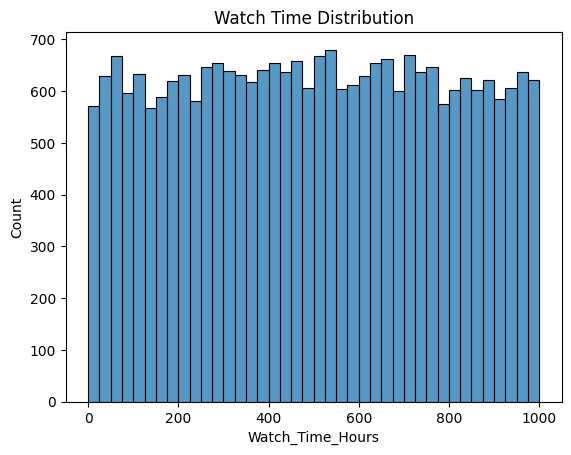

In [ ]:
sns.histplot(users["Watch_Time_Hours"],bins=40)
plt.title("Watch Time Distribution")
plt.show()

Subscription Type

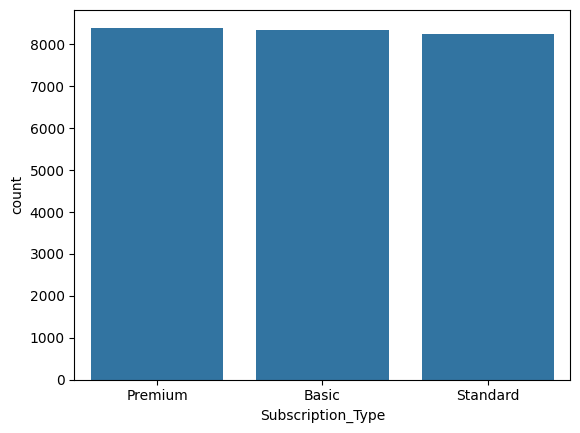

In [ ]:

users["Subscription_Type"].value_counts()
sns.countplot(x="Subscription_Type",data = users)
plt.show()

                         AUDIENCE SEGMENTATION

In [ ]:
def audiencetype(hours):
    if hours <20:
        return "Casual"
    elif hours <50:
        return "Regular"
    else:
        return "Binge"

In [ ]:
users["user_type"] = (users["Watch_Time_Hours"].apply(audiencetype))
users["user_type"]

0          Binge
1          Binge
2        Regular
3          Binge
4          Binge
          ...   
24995      Binge
24996      Binge
24997      Binge
24998      Binge
24999      Binge
Name: user_type, Length: 25000, dtype: str

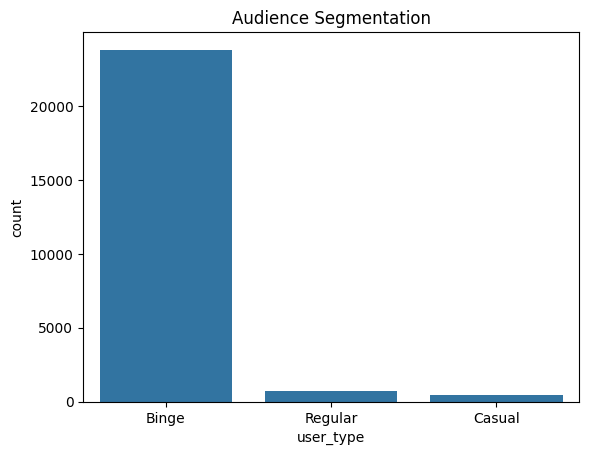

In [ ]:
sns.countplot(
    x="user_type",
    data=users
)

plt.title(
    "Audience Segmentation"
)

plt.show()

                             AGE ANALYSIS

In [ ]:
def age_group(age):
    if age<=18:
        return "Teen"
    elif age<= 30:
        return "Young adult"
    elif age<=50:
        return "adult"
    else:
        return "Senior"

In [ ]:
users.head()

,User_ID,Name,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre,Last_Login,user_type
0,1,James Martinez,18,France,Premium,80.26,Drama,2024-05-12,Binge
1,2,John Miller,23,USA,Premium,321.75,Sci-Fi,2025-02-05,Binge
2,3,Emma Davis,60,UK,Basic,35.89,Comedy,2025-01-24,Regular
3,4,Emma Miller,44,USA,Premium,261.56,Documentary,2024-03-25,Binge
4,5,Jane Smith,68,USA,Standard,909.30,Drama,2025-01-14,Binge


In [ ]:
users["Age_group"] = (users["Age"].apply(age_group))

In [ ]:
age_watch = users.groupby("Age_group")["Watch_Time_Hours"].mean()

In [ ]:
fig = px.bar(age_watch.reset_index(),x ="Age_group",y ="Watch_Time_Hours",title="Average Watch Time by Age Group")
fig.write_image("temp.png")
from IPython.display import Image
Image("temp.png")

                        CONTENT GAP ANALYSIS

In [ ]:
genre_map = {
    "Drama": "Dramas",
    "Comedy": "Comedies",
    "Action": "Action & Adventure",
    "Horror": "Horror Movies",
    "Romance": "Romantic Movies",
    "Documentary": "Documentaries",
    "Sci-Fi": "Sci-Fi & Fantasy"
}

In [ ]:
content_supply = (genre.value_counts().reset_index())

In [ ]:
content_supply.columns = ["Genre","supply"]


In [ ]:
audience_demand = (users["Favorite_Genre"].value_counts().reset_index())
audience_demand.columns = ["Genre","demand"]
audience_demand["Netflix_Genre"] = (
    audience_demand["Genre"]
    .map(genre_map)
)

In [ ]:
gap = pd.merge(
    audience_demand,
    content_supply,
    left_on="Netflix_Genre",
    right_on="Genre",
    how="inner"
)
gap["Demand_supply_ratio"] = (gap["demand"]/gap["supply"])


In [ ]:
gap = gap.sort_values("Demand_supply_ratio",ascending=False)

In [ ]:
fig = px.bar(
    gap,
    x="Netflix_Genre",
    y="Demand_supply_ratio",
    title="Genres Netflix Should Invest More In"
)

fig.write_image("temp.png")
from IPython.display import Image
Image("temp.png")

                                      HEATMAP

In [ ]:
corr = users.select_dtypes(include=np.number).corr()

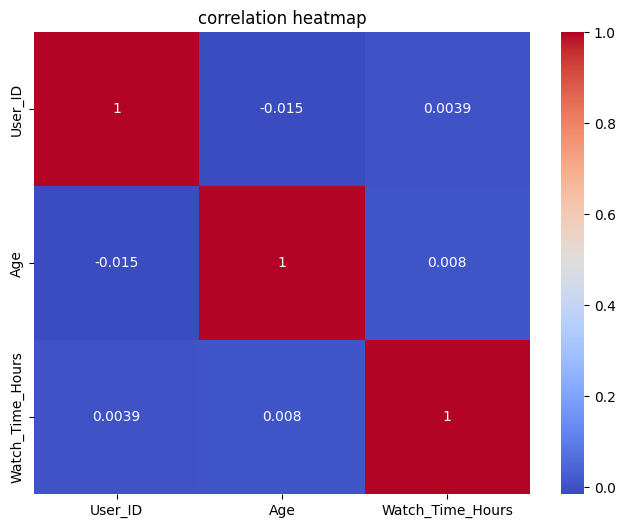

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("correlation heatmap")
plt.show()

                                RECOMMENDATION SYSTEM

In [ ]:
def recommend(country, genre, n=10):
    result = title[
        (title["country"].str.contains(country, case=False, na=False)) &
        (title["listed_in"].str.contains(genre, case=False, na=False))
    ]
    return result[["title", "type", "release_year", "rating"]].head(n)

recommend("India", "Drama")

,title,type,release_year,rating
50,Dharmakshetra,TV Show,2014,TV-PG
69,Stories by Rabindranath Tagore,TV Show,2015,TV-PG
105,Angamaly Diaries,Movie,2017,TV-14
114,Anjaam,Movie,1994,TV-14
116,Dhanak,Movie,2015,TV-PG
118,Gurgaon,Movie,2017,TV-14
126,Shikara,Movie,2020,TV-14
190,Thimmarusu,Movie,2021,TV-14
195,EMI: Liya Hai To Chukana Padega,Movie,2008,TV-14
199,Koi Aap Sa,Movie,2006,TV-14


Conclusion

Key Findings

| # | Finding |
|---|---------|
| 1 | Netflix's catalogue is **70% Movies**, but TV Show production is growing faster |
| 2 | Content volume **peaked in 2018** and has declined — quality over quantity shift |
| 3 | **USA, India, UK** are the top 3 producing nations; K-Drama is a rising force |
| 4 | **International Movies and Dramas** dominate supply |
| 5 | **Sci-Fi (14.2x) and Horror (10.2x)** have the largest demand-supply gap — biggest opportunity |
| 6 | Subscription types are evenly distributed; watch time is uniformly spread across age groups |

Limitations
- `netflix_users.csv` appears to be **synthetically generated** — uniform distributions across watch time, age, and genres are unrealistic. Findings from user analysis should be interpreted with this in mind.
- Country field in `netflix_titles.csv` contains multi-country entries — a more rigorous analysis would explode and deduplicate these.
